In [269]:
from sktime.datasets import load_tsf_to_dataframe
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
import numpy as np
from catboost import CatBoostRegressor
import random
from collections import defaultdict
from abc import ABC, abstractmethod
from scipy.stats import boxcox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
df, metadata = load_tsf_to_dataframe("./m4_yearly_dataset.tsf")

In [4]:
pd.set_option('display.max_rows', None)
print(df.head(36))
pd.reset_option('display.max_rows')

                                           series_value
series_name start_timestamp     timestamp              
T1          1979-01-01 12:00:00 0                5172.1
                                1                5133.5
                                2                5186.9
                                3                5084.6
                                4                5182.0
                                5                5414.3
                                6                5576.2
                                7                5752.9
                                8                5955.2
                                9                6087.8
                                10               6238.9
                                11               6317.2
                                12               6262.7
                                13               6361.0
                                14               6427.4
                                15              

In [5]:
df_reset = df.reset_index()
print(df_reset['series_name'].unique())

['T1' 'T2' 'T3' ... 'T22998' 'T22999' 'T23000']


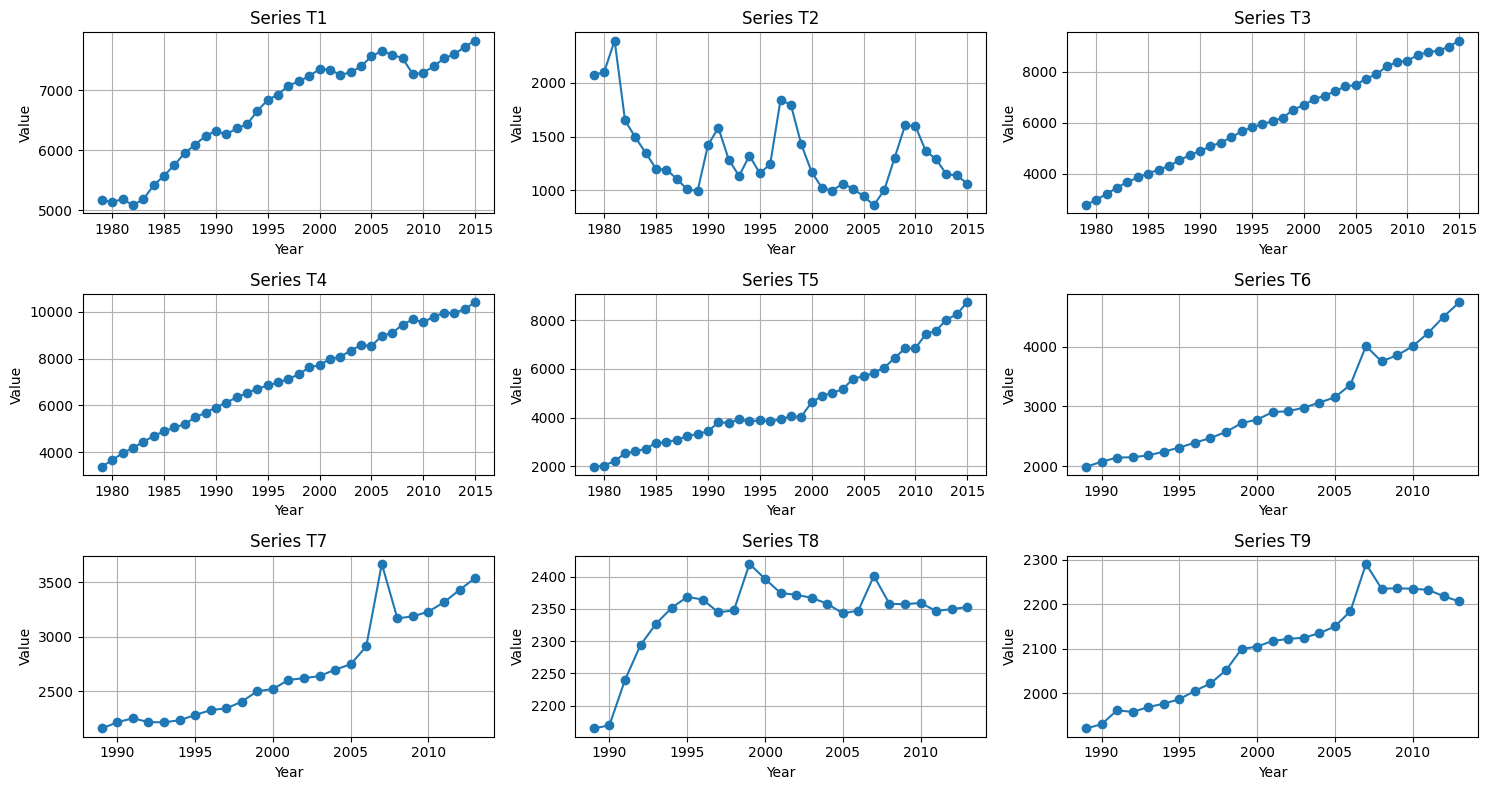

In [29]:
series_names = df_reset['series_name'].unique()[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

for i, name in enumerate(series_names):
    series_data = df_reset[df_reset['series_name'] == name].copy()
    start_year = pd.to_datetime(series_data['start_timestamp'].iloc[0]).year
    series_data['year'] = start_year + series_data['timestamp']
    
    axes[i].plot(series_data['year'], series_data['series_value'], marker='o', linestyle='-')
    axes[i].set_title(f'Series {name}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [6]:
grouped = df_reset.groupby('series_name')['series_value'].apply(list).reset_index()
grouped.columns = ['series_name', 'values']  

grouped = grouped[grouped['values'].apply(len) >= 40]

grouped = grouped.sort_values('series_name')

selected = grouped.head(150)

series_list = selected['values'].tolist()
series_names = selected['series_name'].tolist()

print(f"Отобрано {len(series_list)} рядов с длиной >= 40")
print("Минимальная длина среди отобранных:", min(len(v) for v in series_list))
print("Средняя длина среди отобранных:", np.mean([len(v) for v in series_list]))

Отобрано 150 рядов с длиной >= 40
Минимальная длина среди отобранных: 40
Средняя длина среди отобранных: 51.04666666666667


In [8]:
X = to_time_series_dataset(series_list)
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

Обучаем модель с k=1...
Обучаем модель с k=2...
Обучаем модель с k=3...
Обучаем модель с k=4...
Обучаем модель с k=5...
Обучаем модель с k=6...
Обучаем модель с k=7...
Обучаем модель с k=8...
Обучаем модель с k=9...
Обучаем модель с k=10...


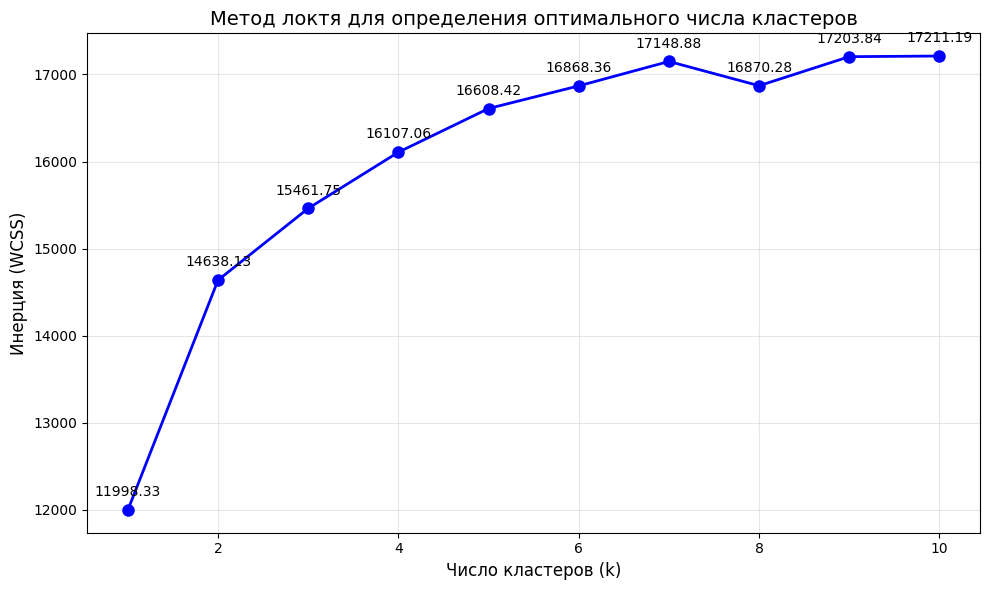


Таблица инерции по числу кластеров:
k	Инерция
1	11998.33
2	14638.13
3	15461.75
4	16107.06
5	16608.42
6	16868.36
7	17148.88
8	16870.28
9	17203.84
10	17211.19


In [ ]:
k_range = range(1, 11)
inertias = []

for k in k_range:
    print(f"Обучаем модель с k={k}...")

    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="softdtw",
        max_iter=50,
        max_iter_barycenter=10,
        random_state=0,
        verbose=0
    ).fit(X_scaled)

    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров (k)', fontsize=12)
plt.ylabel('Инерция (WCSS)', fontsize=12)
plt.title('Метод локтя для определения оптимального числа кластеров', fontsize=14)
plt.grid(True, alpha=0.3)

for i, inertia in enumerate(inertias):
    plt.annotate(f'{inertia:.2f}', (k_range[i], inertia),
                 textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

print("\nТаблица инерции по числу кластеров:")
print("k\tИнерция")
for k, inertia in zip(k_range, inertias):
    print(f"{k}\t{inertia:.2f}")


In [9]:
km_dba = TimeSeriesKMeans(
    n_clusters=7,
    metric="softdtw",
    max_iter=5,
    max_iter_barycenter=5,
    random_state=0
).fit(X_scaled)

cluster_labels = km_dba.labels_
print("Метки кластеров:", cluster_labels)

Метки кластеров: [4 3 3 5 1 5 6 2 0 1 6 0 4 0 5 3 3 3 3 1 3 3 4 4 3 3 6 6 5 1 4 6 4 2 5 3 2
 4 3 6 3 2 3 5 0 1 3 5 4 1 1 2 5 5 4 5 4 4 3 3 6 5 1 5 3 6 4 5 5 1 1 3 5 4
 3 4 5 5 1 1 3 4 5 4 5 2 5 3 1 2 6 1 6 5 3 3 4 6 1 1 6 4 0 3 4 1 2 0 2 0 0
 3 3 3 0 2 1 1 1 1 1 6 2 2 2 1 3 3 1 2 3 6 3 6 2 1 3 3 3 2 2 1 1 2 1 1 6 5
 3 2]


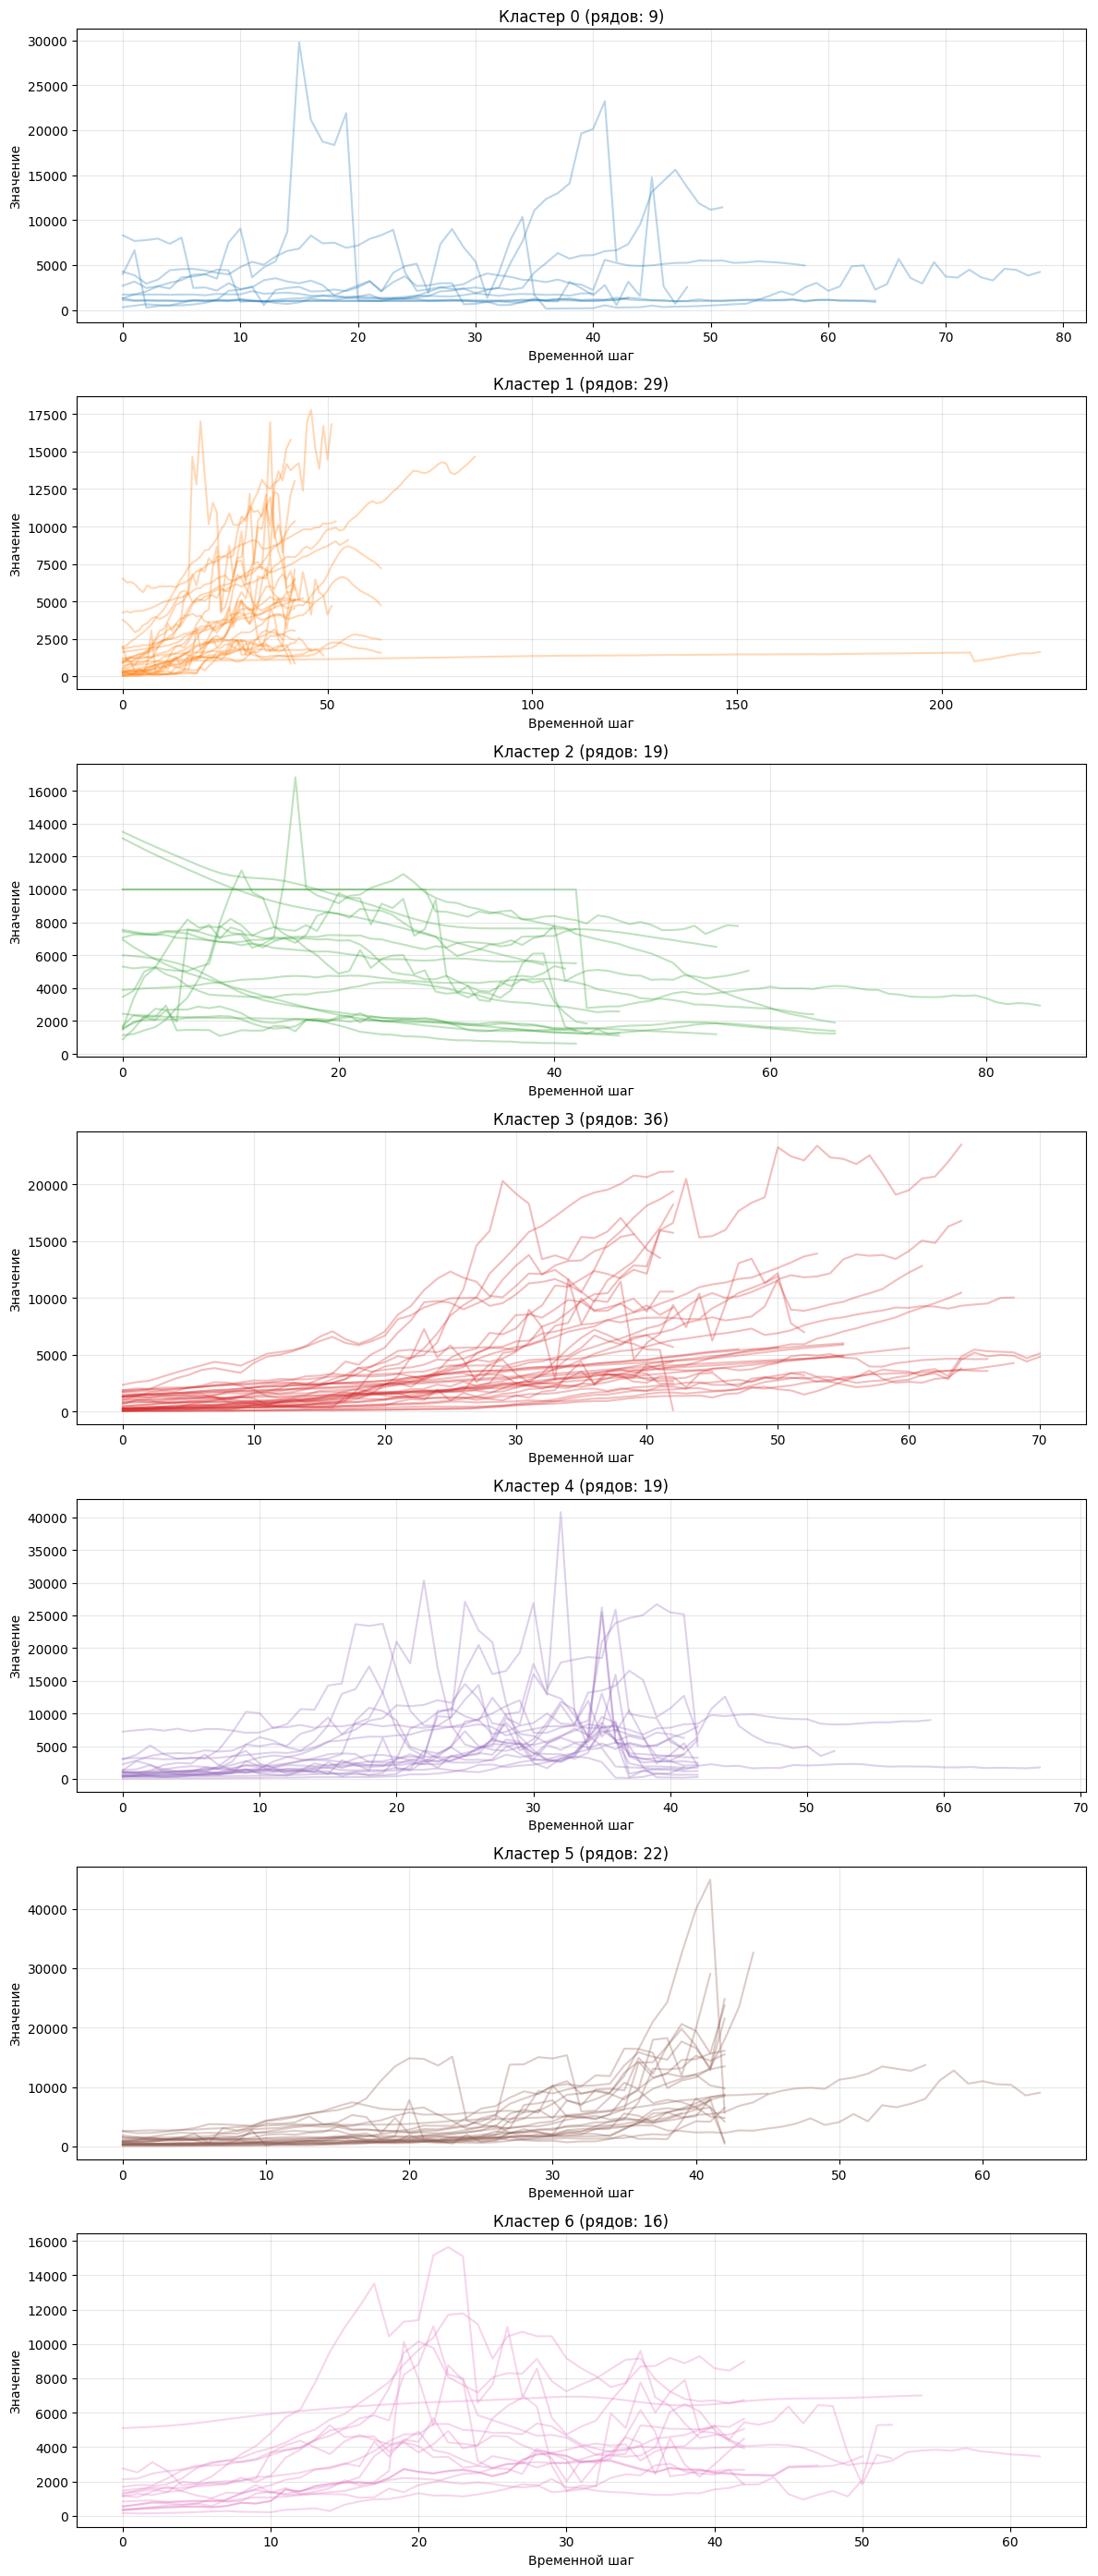

In [10]:
centroids = km_dba.cluster_centers_
n_clusters = len(centroids)

fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 4 * n_clusters))
if n_clusters == 1:
    axes = [axes]

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]    
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    for idx in cluster_indices:
        series_values = series_list[idx]   # значения ряда
        ax.plot(series_values, alpha=0.3, color=f'C{cluster_id}')
    
    ax.set_title(f'Кластер {cluster_id} (рядов: {len(cluster_indices)})')
    ax.set_xlabel('Временной шаг')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))

naive_smape_list = []
for values in series_list:
    train = values[:-6]
    test = values[-6:]
    naive_forecast = np.full(6, train[-1])  
    naive_smape_list.append(smape(test, naive_forecast))

unique_clusters = np.unique(cluster_labels)
for cl in unique_clusters:
    indices = np.where(cluster_labels == cl)[0]
    smapes_cluster = [naive_smape_list[i] for i in indices]
    mean_smape = np.mean(smapes_cluster)
    lengths_cluster = [len(series_list[i]) for i in indices]  
    mean_length = np.mean(lengths_cluster) 
    
    print(f"Кластер {cl}: {len(indices)} рядов, средний Naïve sMAPE = {mean_smape:.2f}, средняя длина ряда = {mean_length:.1f}")


Кластер 0: 9 рядов, средний Naïve sMAPE = 23.95, средняя длина ряда = 55.2
Кластер 1: 29 рядов, средний Naïve sMAPE = 15.41, средняя длина ряда = 55.5
Кластер 2: 19 рядов, средний Naïve sMAPE = 13.78, средняя длина ряда = 53.7
Кластер 3: 36 рядов, средний Naïve sMAPE = 13.57, средняя длина ряда = 53.7
Кластер 4: 19 рядов, средний Naïve sMAPE = 75.29, средняя длина ряда = 45.5
Кластер 5: 22 рядов, средний Naïve sMAPE = 38.76, средняя длина ряда = 44.6
Кластер 6: 16 рядов, средний Naïve sMAPE = 26.32, средняя длина ряда = 46.9


In [176]:
def plot_predictions(
        predictions_list,
        true_list,
        series_list,
        row_index_list,
        cluster_for_plot,
        L = 35,
        max_plots = 5,
        ):
    if len(predictions_list) > 0:
        n_plots = min(max_plots, len(predictions_list))
        sample_indices = random.sample(range(len(predictions_list)), n_plots)

        plt.figure(figsize=(15, 3 * n_plots))
        for i, idx_in_list in enumerate(sample_indices):
            plot_idx = row_index_list[idx_in_list]
            cluster_id = cluster_for_plot[idx_in_list]
            true_vals = true_list[idx_in_list]
            pred_vals = predictions_list[idx_in_list]

            values = series_list[plot_idx]
            N = len(values)

            hist_indices = list(range(N - 6 - L, N - 6))
            history = values[N - 6 - L:N - 6]
            test_indices = list(range(N - 6, N))

            plt.subplot(n_plots, 1, i + 1)
            plt.plot(hist_indices, history, 'b-o', label='История', markersize=4)
            plt.plot(test_indices, true_vals, 'g-o', label='Факт', markersize=4)
            plt.plot(test_indices, pred_vals, 'r--o', label='Прогноз CatBoost', markersize=4)
            naive = [history[-1]] * 6
            plt.plot(test_indices, naive, 'k:', label='Naïve', markersize=4)

            plt.title(f'Ряд {plot_idx}, кластер {cluster_id}')
            plt.xlabel('Индекс ряда')
            plt.ylabel('Значение')
            plt.legend()
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных для визуализации прогнозов")

In [144]:
def print_smape(catboost_smape_list, cluster_labels):
    unique_clusters = np.unique(cluster_labels)
    print("CatBoost sMAPE по кластерам:")
    for cl in unique_clusters:
        indices = np.where(cluster_labels == cl)[0]
        valid_smapes = [catboost_smape_list[i] for i in indices if not np.isnan(catboost_smape_list[i])]
        if len(valid_smapes) > 0:
            mean_smape = np.mean(valid_smapes)
            print(f"Кластер {cl}: {len(valid_smapes)} рядов из {len(indices)}, средний CatBoost sMAPE = {mean_smape:.2f}")
        else:
            print(f"Кластер {cl}: нет данных для расчёта")

In [145]:
H = 6
L = 35
feature_names = [f'lag_{i}' for i in range(L)]

## Преобразования рядов

В задании предлагается сравнивать бейзлайн с несколькими типами преобразований:

In [265]:
class BaseTransform(ABC):
    @abstractmethod
    def fit(self, series_list):
        pass
    
    @abstractmethod
    def transform(self, series_list):
        pass 

    @abstractmethod
    def inverse(self, series_list):
        pass

class NullTransform(BaseTransform):
    def fit(self, series_list):
        return series_list
    
    def transform(self, series_list):
        return series_list 

    def inverse(self, series_list):
        return series_list

class Log1pTransform(BaseTransform):
    def fit(self, series_list):
        self.shifts = []
        result = []
        for s in series_list:
            s = np.asarray(s, dtype=np.float64)
            shift = 0.0
            if s.min() < 0:
                shift = abs(s.min()) + 1e-8
                s = s + shift
            result.append(np.log1p(s))
            self.shifts.append(shift)
        return result

    def transform(self, series_list):
        result = []
        for s, shift in zip(series_list, self.shifts):
            s = np.asarray(s, dtype=np.float64)
            if shift != 0:
                s = s + shift
            result.append(np.log1p(s))
        return result

    def inverse(self, series_list):
        result = []
        for s, shift in zip(series_list, self.shifts):
            x = np.expm1(s)
            if shift != 0:
                x = x - shift
            result.append(x)
        return result

class DiffTransform(BaseTransform):
    def __init__(self, order=1):
        self.order = order
        self.last_values = []

    def fit(self, series_list):
        self.last_values = []
        result = []
        for s in series_list:
            s = np.asarray(s, dtype=np.float64)
            self.last_values.append(s[-self.order:].copy())
            diff = s.copy()
            for _ in range(self.order):
                diff = np.diff(diff)
            result.append(diff)
        return result

    def transform(self, series_list):
        result = []
        for s, last in zip(series_list, self.last_values):
            diff = s.copy()
            for _ in range(self.order):
                diff = np.diff(diff)
            result.append(diff)
        return result

    def inverse(self, series_list):
        result = []
        for s, last in zip(series_list, self.last_values):
            restored = s.copy()
            for i in range(self.order):
                restored = np.r_[last[self.order - 1 - i], restored].cumsum()
            result.append(restored[-len(s):])
        return result

class BoxCoxTransform(BaseTransform):
    def __init__(self):
        self.lambdas = []
        self.shifts = []

    def fit(self, series_list):
        self.lambdas = []
        self.shifts = []
        result = []

        for s in series_list:
            s = np.asarray(s, dtype=np.float64)
            shift = 0.0
            if np.any(s <= 0):
                shift = abs(np.min(s)) + 1e-8
                s = s + shift
            transformed, lam = boxcox(s)
            result.append(transformed)
            self.lambdas.append(lam)
            self.shifts.append(shift)

        return result

    def transform(self, series_list):
        result = []
        for s, lam, shift in zip(series_list, self.lambdas, self.shifts):
            s = np.asarray(s, dtype=np.float64)
            if shift != 0:
                s = s + shift
            if abs(lam) < 1e-8:
                transformed = np.log(s)
            else:
                transformed = (np.power(s, lam) - 1) / lam
            result.append(transformed)
        return result

    def inverse(self, series_list):
        result = []
        for s, lam, shift in zip(series_list, self.lambdas, self.shifts):
            s = np.asarray(s, dtype=np.float64)
            
            s = np.clip(s, -1e8, 1e8)

            if abs(lam) < 1e-8:
                inv = np.exp(s)
            else:
                base = lam * s + 1
                base = np.minimum(np.maximum(base, 1e-12), 1e12)   # защита от переполнения
                inv = np.power(base, 1 / lam)

            if shift != 0:
                inv = inv - shift

            result.append(inv)
        return result

Внутри обучения будет использовать паттерн пайплайн для преобразований:

In [214]:
class TransformPipeline:
    def __init__(self, transforms):
        self.transforms = transforms

    def fit_transform(self, series_list):
        data = series_list
        for t in self.transforms:
            data = t.fit(data)
        return data

    def transform(self, series_list):
        data = series_list
        for t in self.transforms:
            data = t.transform(data)
        return data

    def inverse(self, series_list):
        data = series_list
        for t in reversed(self.transforms):
            data = t.inverse(data)
        return data

Теперь нужны методы для получение датасета, обучения и инференса модели:

In [ ]:
def get_train(series_list, cluster_labels, H=6, L=35):
    X, y = [], []
    for idx, s in enumerate(series_list):
        cluster = cluster_labels[idx]
        N = len(s)
        if N >= L + H:
            for t in range(L, N - H + 1):
                feats = s[t-L:t]
                # Добавляем кластера, чтобы идентфицировать ряд
                X.append(np.append(feats, cluster))
                y.append(s[t:t+H])
    
    feature_names = [f'lag_{i}' for i in range(L)] + ['cluster']
    X = pd.DataFrame(X, columns=feature_names)
    X['cluster'] = X['cluster'].astype(int)
    return X, np.array(y), feature_names

def fit_models(X, y):
    models = {}
    for cluster in sorted(X["cluster"].unique()):
        mask = X["cluster"] == cluster
        x_train = X.loc[mask].drop(columns="cluster")
        y_train = y[mask]
        model = CatBoostRegressor(loss_function='MultiRMSE', iterations=1000, depth=6, verbose=3)
        model.fit(x_train, y_train)
        models[cluster] = model
    return models

def predict(
    models,
    raw_series_list,
    cluster_labels,
    pipeline,
    feature_names,
    H=6,
    L=35,
):
    transformed = pipeline.transform(raw_series_list)

    predictions = []
    true = []
    row_indices = []

    for idx, s in enumerate(transformed):
        cluster = cluster_labels[idx]
        N = len(s)

        if N < L + H:
            continue

        feats = s[N - H - L:N - H]
        X_test = pd.DataFrame(
            [feats],
            columns=feature_names[:-1]
        )

        model = models[cluster]
        pred = model.predict(X_test).flatten()

        predictions.append(pred)
        true.append(raw_series_list[idx][-H:])
        row_indices.append(idx)

    for t in pipeline.transforms:
        # В дифференцировании возникает проблема с индексми,
        # для этого мы приводим индексы в соответсвии
        # с порядком дифференцирования
        if isinstance(t, DiffTransform):
            t.last_values = [
                raw_series_list[idx][-H - t.order:-H]
                for idx in row_indices
            ]

    pred_real = pipeline.inverse(predictions)

    return pred_real, true, row_indices

Бейзлайн прогнозы:

In [ ]:
def naive_forecast(series, H=6):
    return np.array([series[-1]] * H)

def theta_forecast(series, H=6):
    series = np.asarray(series)
    slope = series[-1] - series[-2] if len(series) >= 2 else 0
    return series[-1] + slope * np.arange(1, H+1)

def ets_forecast(series, H=6):
    series = np.asarray(series)
    if len(series) < 2:
        return np.array([series[-1]] * H)
    try:
        model = ExponentialSmoothing(series, trend='add', seasonal=None)
        fit = model.fit()
        return fit.forecast(H)
    except Exception:
        return np.array([series[-1]] * H)

Функции для метрик представлены тут:

In [245]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)

    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)

def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

In [255]:
def evaluate_all(pred_list, true_list):
    smape_list, mae_list, rmse_list = [], [], []

    for pred, true in zip(pred_list, true_list):
        smape_list.append(smape(true, pred))
        mae_list.append(mae(true, pred))
        rmse_list.append(rmse(true, pred))

    return {
        "SMAPE_mean": np.mean(smape_list),
        "MAE_mean": np.mean(mae_list),
        "RMSE_mean": np.mean(rmse_list),
        "SMAPE_all": smape_list,
    }


def evaluate_all_by_cluster(pred_list, true_list, cluster_labels):
    cluster_metrics = defaultdict(lambda: {"SMAPE": [], "MAE": [], "RMSE": []})
    smape_all, mae_all, rmse_all = [], [], []

    for pred, true, cl in zip(pred_list, true_list, cluster_labels):
        s = smape(true, pred)
        m = mae(true, pred)
        r = rmse(true, pred)

        cluster_metrics[cl]["SMAPE"].append(s)
        cluster_metrics[cl]["MAE"].append(m)
        cluster_metrics[cl]["RMSE"].append(r)

        smape_all.append(s)
        mae_all.append(m)
        rmse_all.append(r)

    rows = []
    for cl, metrics in cluster_metrics.items():
        rows.append({
            "cluster": cl,
            "SMAPE_mean": np.mean(metrics["SMAPE"]),
            "MAE_mean": np.mean(metrics["MAE"]),
            "RMSE_mean": np.mean(metrics["RMSE"])
        })

    rows.append({
        "cluster": "overall",
        "SMAPE_mean": np.mean(smape_all),
        "MAE_mean": np.mean(mae_all),
        "RMSE_mean": np.mean(rmse_all)
    })

    df = pd.DataFrame(rows)
    return df

И функция для отрисовки:

In [248]:
def plot_forecasts(
    series_list,
    pred_real,
    true,
    row_indices,
    cluster_labels,
    H=6,
    n_rows=5
):
    for i, idx in enumerate(row_indices):
        history = series_list[idx]
        test_start = len(history) - H
        test_indices = np.arange(test_start, len(history))
        hist_indices = np.arange(len(history))
        
        naive = np.array([history[-H-1]]*H)

        plt.figure(figsize=(10,4))
        plt.plot(hist_indices, history, 'b-o', label='История', markersize=4)
        plt.plot(test_indices, true[i], 'g-o', label='Факт', markersize=4)
        plt.plot(test_indices, pred_real[i], 'r--o', label='Прогноз CatBoost', markersize=4)
        plt.plot(test_indices, naive, 'k--', label='Наивный прогноз', markersize=4)
        
        plt.title(f'Ряд {idx}, кластер {cluster_labels[idx]}')
        plt.xlabel('t')
        plt.ylabel('Значение')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        if i + 1 >= n_rows:
            break

## Бейзлайны (без трансформаций)

### Naive

### Auto Theta

### Auto ETS

### CatBoost

In [266]:
pipeline = TransformPipeline([NullTransform()])
transformed = pipeline.fit_transform(series_list)
X_train, y_train, feature_names = get_train(transformed, cluster_labels)
models = fit_models(X_train, y_train)

pred_real, true, row_indices = predict(
    models, series_list, cluster_labels, pipeline, feature_names
)

0:	learn: 8563.4004852	total: 14.6ms	remaining: 14.6s
3:	learn: 8180.7073745	total: 22.3ms	remaining: 5.54s
6:	learn: 7819.8234381	total: 27.8ms	remaining: 3.94s
9:	learn: 7490.6448730	total: 33ms	remaining: 3.27s
12:	learn: 7194.6826685	total: 37.9ms	remaining: 2.88s
15:	learn: 6903.9564891	total: 44ms	remaining: 2.7s
18:	learn: 6655.0335296	total: 49.4ms	remaining: 2.55s
21:	learn: 6399.7898387	total: 54.7ms	remaining: 2.43s
24:	learn: 6146.6126829	total: 60.8ms	remaining: 2.37s
27:	learn: 5932.3248782	total: 66ms	remaining: 2.29s
30:	learn: 5691.8885446	total: 71.3ms	remaining: 2.23s
33:	learn: 5497.7427747	total: 77.8ms	remaining: 2.21s
36:	learn: 5325.4221987	total: 83.7ms	remaining: 2.18s
39:	learn: 5154.5673199	total: 89.3ms	remaining: 2.14s
42:	learn: 4994.9553159	total: 94.8ms	remaining: 2.11s
45:	learn: 4869.3173767	total: 100ms	remaining: 2.08s
48:	learn: 4722.0647289	total: 106ms	remaining: 2.05s
51:	learn: 4586.4893655	total: 111ms	remaining: 2.02s
54:	learn: 4450.4457527	

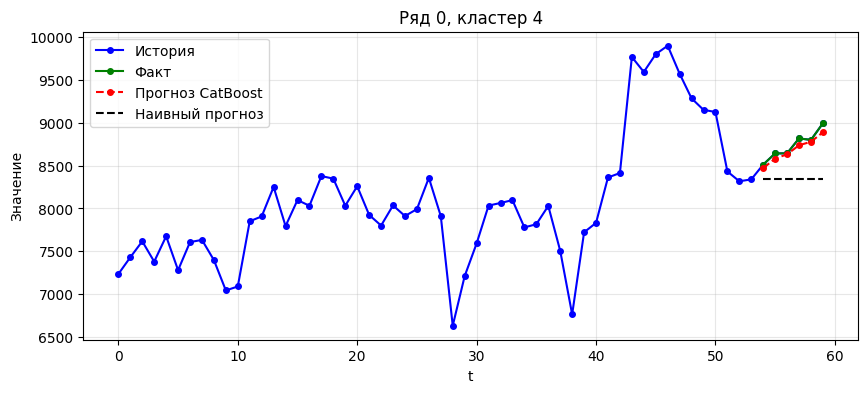

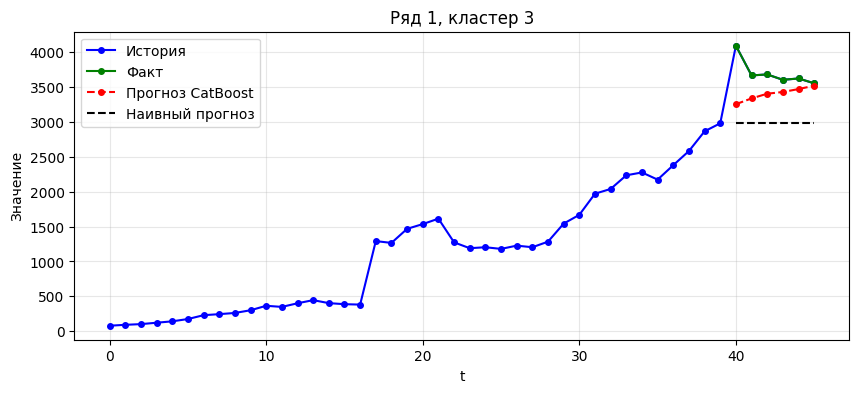

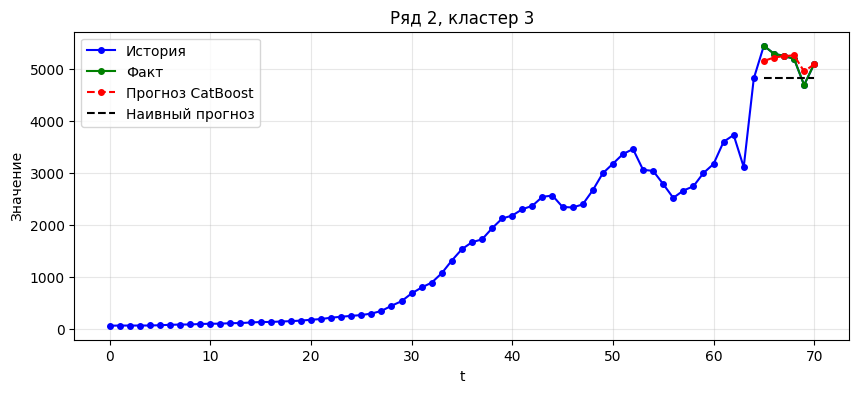

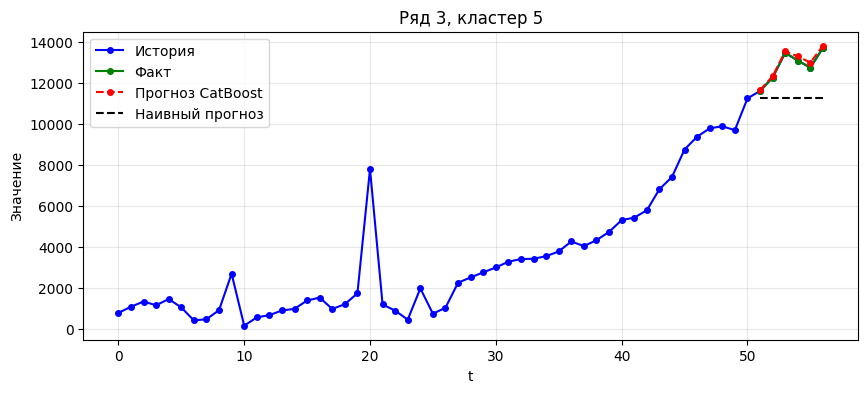

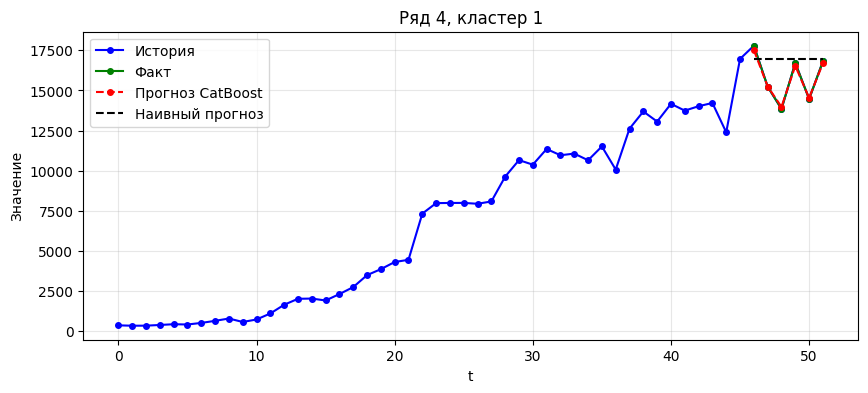

In [267]:
plot_forecasts(series_list, pred_real, true, row_indices, cluster_labels)

In [268]:
evaluate_all_by_cluster(pred_real, true, cluster_labels)

,cluster,SMAPE_mean,MAE_mean,RMSE_mean
0,4,3.400629,149.591778,174.548007
1,3,4.690659,127.936180,146.654529
2,5,2.741432,136.954863,162.381293
3,1,2.581141,128.880168,152.446444
4,6,3.192708,129.440244,149.319440
5,2,3.671436,139.855524,163.121108
6,0,7.696247,197.495899,249.742804
7,overall,3.729116,138.151050,162.355695


## Log1p трансформация

In [257]:
pipeline = TransformPipeline([Log1pTransform()])
transformed = pipeline.fit_transform(series_list)
X_train, y_train, feature_names = get_train(transformed, cluster_labels)
models = fit_models(X_train, y_train)

pred_real, true, row_indices = predict(
    models, series_list, cluster_labels, pipeline, feature_names
)

0:	learn: 2.4444374	total: 13.9ms	remaining: 13.9s
3:	learn: 2.3272604	total: 21.6ms	remaining: 5.38s
6:	learn: 2.2214301	total: 29.4ms	remaining: 4.17s
9:	learn: 2.1274551	total: 37.4ms	remaining: 3.7s
12:	learn: 2.0381252	total: 43.3ms	remaining: 3.29s
15:	learn: 1.9513685	total: 48.5ms	remaining: 2.98s
18:	learn: 1.8720722	total: 55.2ms	remaining: 2.85s
21:	learn: 1.8006727	total: 61.2ms	remaining: 2.72s
24:	learn: 1.7309958	total: 66.7ms	remaining: 2.6s
27:	learn: 1.6592572	total: 72ms	remaining: 2.5s
30:	learn: 1.5973916	total: 78ms	remaining: 2.44s
33:	learn: 1.5422074	total: 83.4ms	remaining: 2.37s
36:	learn: 1.4840119	total: 88.7ms	remaining: 2.31s
39:	learn: 1.4319347	total: 94.5ms	remaining: 2.27s
42:	learn: 1.3866043	total: 99.8ms	remaining: 2.22s
45:	learn: 1.3438872	total: 105ms	remaining: 2.17s
48:	learn: 1.3051171	total: 110ms	remaining: 2.14s
51:	learn: 1.2676099	total: 115ms	remaining: 2.1s
54:	learn: 1.2291625	total: 121ms	remaining: 2.07s
57:	learn: 1.1949939	total: 

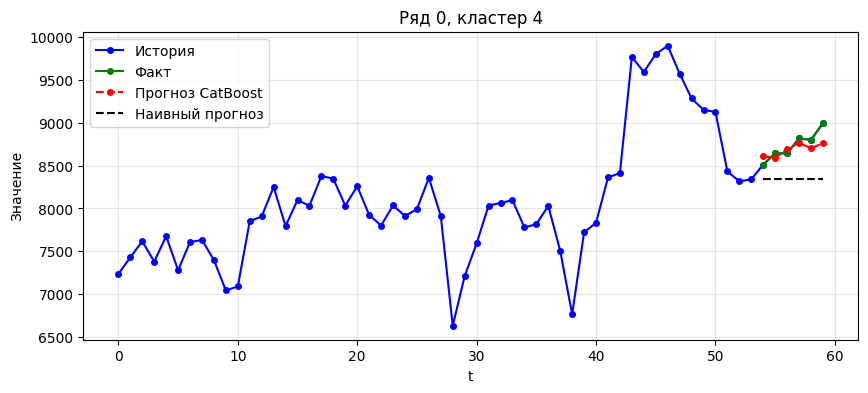

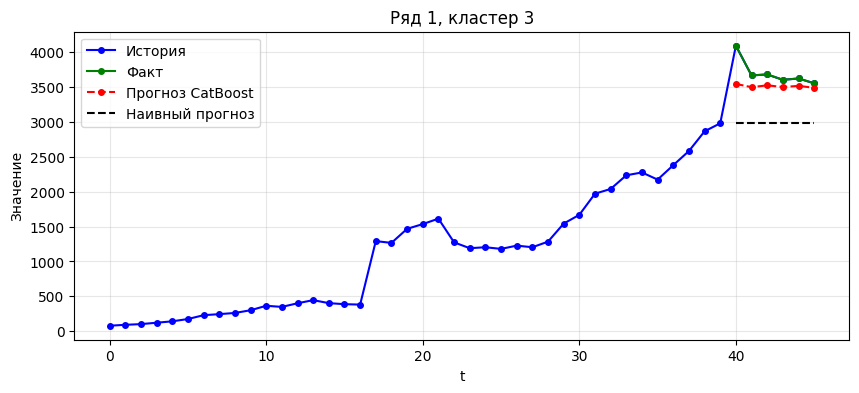

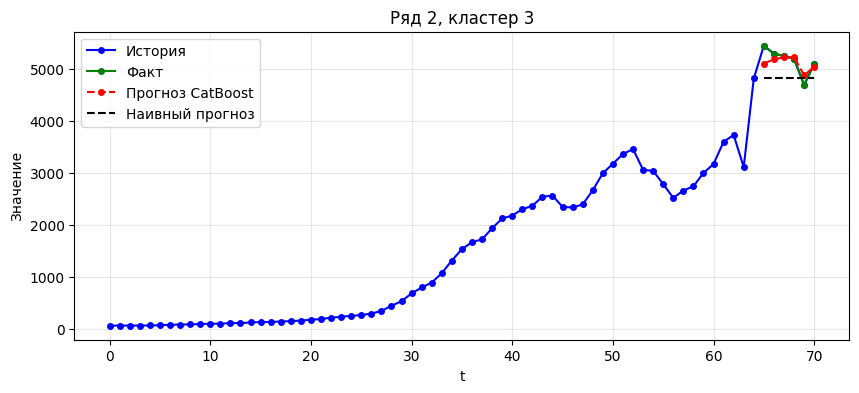

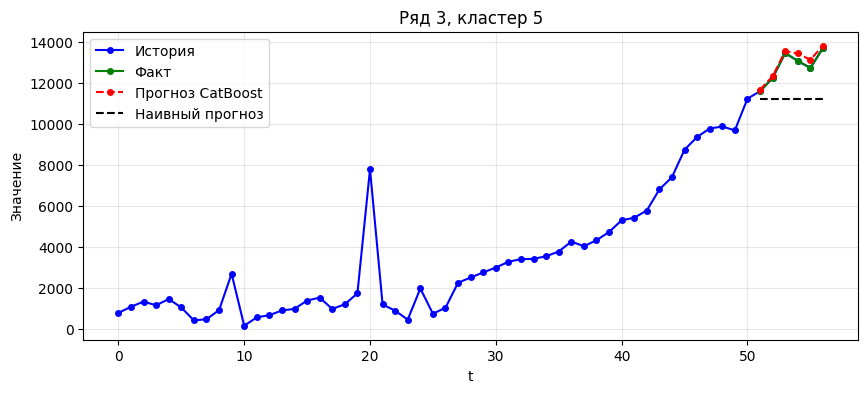

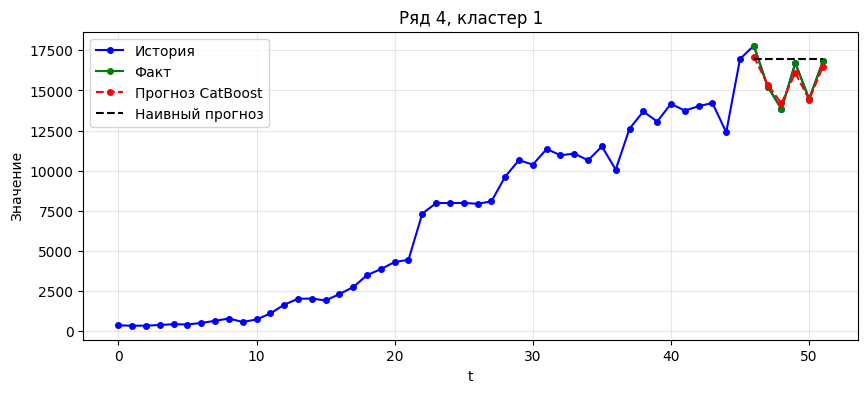

In [258]:
plot_forecasts(series_list, pred_real, true, row_indices, cluster_labels)

In [259]:
evaluate_all_by_cluster(pred_real, true, cluster_labels)

,cluster,SMAPE_mean,MAE_mean,RMSE_mean
0,4,2.934209,271.114211,307.898684
1,3,2.750509,140.706644,162.186393
2,5,2.405260,176.824127,218.172972
3,1,2.355920,162.510825,190.870050
4,6,1.949896,135.699905,161.958422
5,2,2.618301,165.648892,189.236060
6,0,3.400462,164.055835,207.680929
7,overall,2.587890,171.203454,201.015181


## Дифференцирование

In [252]:
pipeline = TransformPipeline([DiffTransform()])
transformed = pipeline.fit_transform(series_list)
X_train, y_train, feature_names = get_train(transformed, cluster_labels)
models = fit_models(X_train, y_train)

pred_real, true, row_indices = predict(
    models, series_list, cluster_labels, pipeline, feature_names
)

0:	learn: 4041.8669920	total: 8.05ms	remaining: 8.04s
3:	learn: 3994.8600148	total: 13.4ms	remaining: 3.35s
6:	learn: 3934.4090157	total: 21.4ms	remaining: 3.03s
9:	learn: 3884.0227720	total: 27.2ms	remaining: 2.69s
12:	learn: 3827.0627796	total: 32.6ms	remaining: 2.48s
15:	learn: 3762.2349575	total: 38ms	remaining: 2.34s
18:	learn: 3706.5536312	total: 43.4ms	remaining: 2.24s
21:	learn: 3663.8814595	total: 48.6ms	remaining: 2.16s
24:	learn: 3617.3466208	total: 53.7ms	remaining: 2.1s
27:	learn: 3573.5649713	total: 58.5ms	remaining: 2.03s
30:	learn: 3525.1496849	total: 63.7ms	remaining: 1.99s
33:	learn: 3470.9172631	total: 68.6ms	remaining: 1.95s
36:	learn: 3423.8717852	total: 73.8ms	remaining: 1.92s
39:	learn: 3373.6037047	total: 79.7ms	remaining: 1.91s
42:	learn: 3334.4155256	total: 85.3ms	remaining: 1.9s
45:	learn: 3290.0249401	total: 90.4ms	remaining: 1.87s
48:	learn: 3245.5677054	total: 95.8ms	remaining: 1.86s
51:	learn: 3199.5961355	total: 101ms	remaining: 1.84s
54:	learn: 3146.422

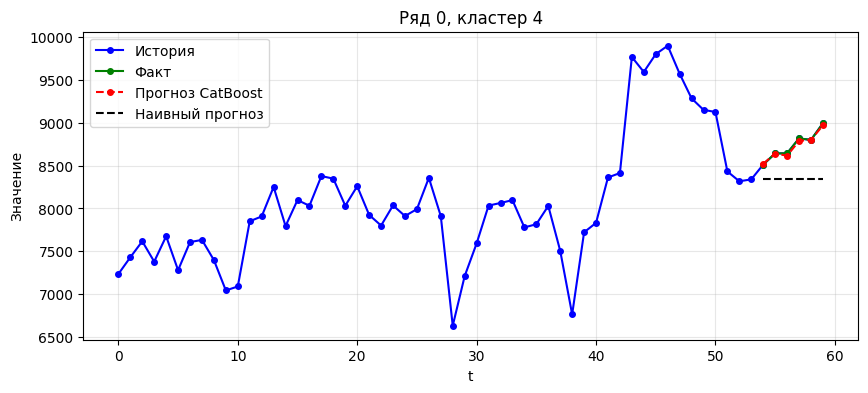

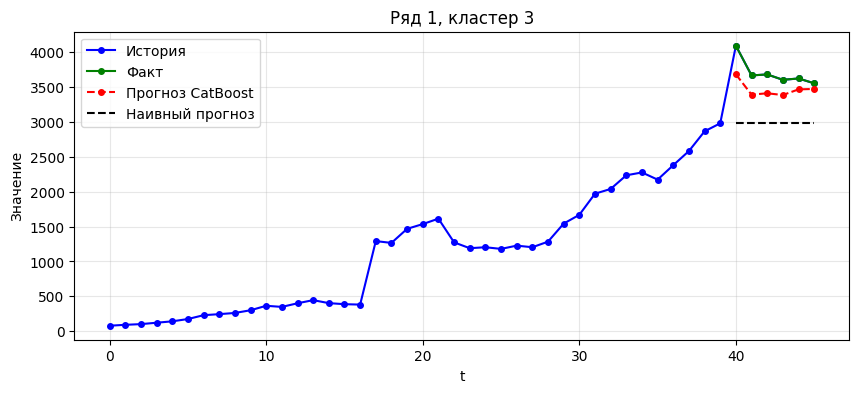

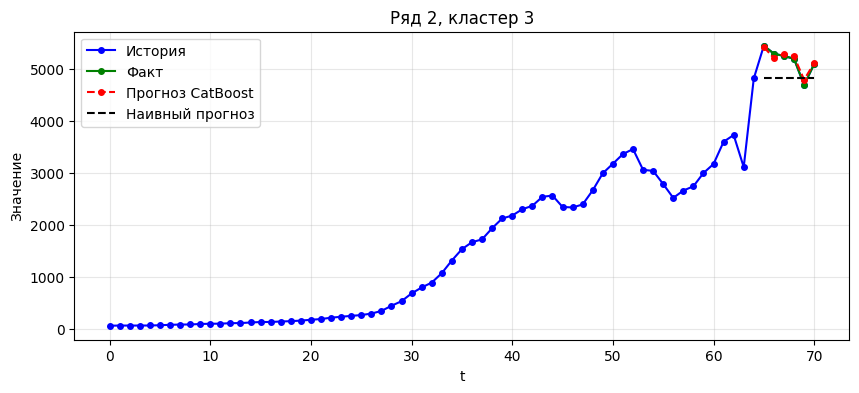

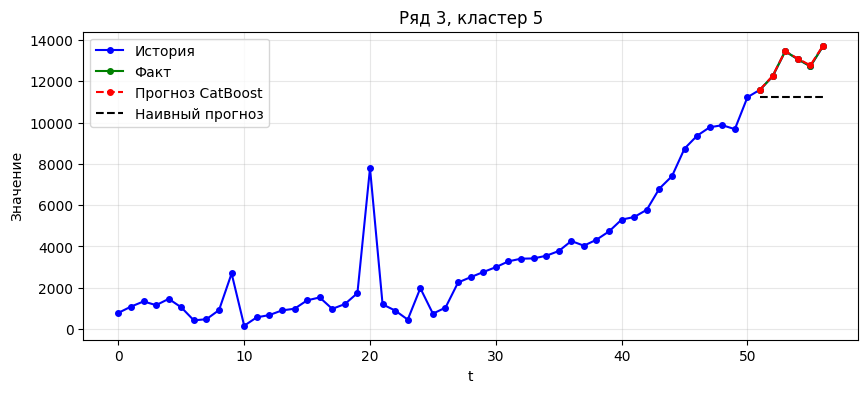

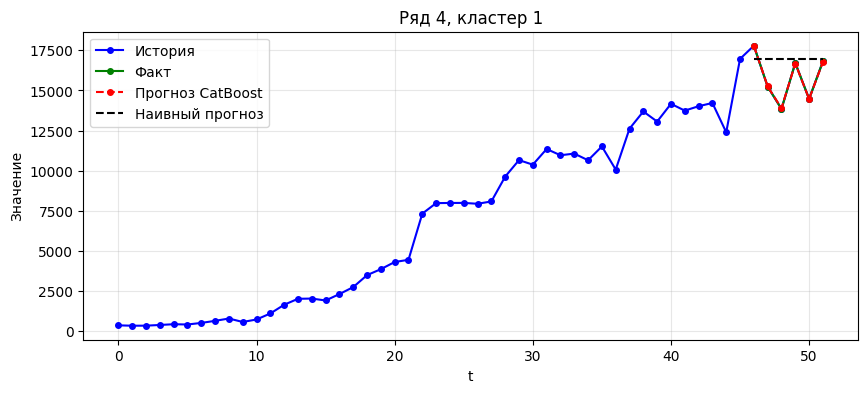

In [253]:
plot_forecasts(series_list, pred_real, true, row_indices, cluster_labels)

In [256]:
evaluate_all_by_cluster(pred_real, true, cluster_labels)

,cluster,SMAPE_mean,MAE_mean,RMSE_mean
0,4,1.567385,79.448965,86.250023
1,3,2.119713,61.574723,67.863155
2,5,3.559769,77.641682,89.752731
3,1,1.433167,46.903563,53.635836
4,6,1.197912,43.070402,50.746735
5,2,1.769897,80.706392,96.095299
6,0,3.869244,56.510906,71.173435
7,overall,2.097715,63.672822,72.766758


## BoxCox

In [260]:
pipeline = TransformPipeline([BoxCoxTransform()])
transformed = pipeline.fit_transform(series_list)
X_train, y_train, feature_names = get_train(transformed, cluster_labels)
models = fit_models(X_train, y_train)

pred_real, true, row_indices = predict(
    models, series_list, cluster_labels, pipeline, feature_names
)

0:	learn: 286.8949720	total: 10.2ms	remaining: 10.2s
3:	learn: 280.2640019	total: 15.9ms	remaining: 3.96s
6:	learn: 274.5940552	total: 20.2ms	remaining: 2.87s
9:	learn: 269.7238228	total: 25ms	remaining: 2.47s
12:	learn: 265.0677501	total: 27.9ms	remaining: 2.11s
15:	learn: 259.0167181	total: 31.8ms	remaining: 1.95s
18:	learn: 253.1236781	total: 35.8ms	remaining: 1.85s
21:	learn: 247.7336102	total: 39.6ms	remaining: 1.76s
24:	learn: 243.4727794	total: 43.6ms	remaining: 1.7s
27:	learn: 237.9696717	total: 47.5ms	remaining: 1.65s
30:	learn: 232.5979982	total: 51ms	remaining: 1.59s
33:	learn: 228.6999330	total: 54.7ms	remaining: 1.55s
36:	learn: 223.5457727	total: 58.6ms	remaining: 1.52s
39:	learn: 218.8378281	total: 62.3ms	remaining: 1.5s
42:	learn: 213.9155172	total: 65.9ms	remaining: 1.47s
45:	learn: 210.3010538	total: 69.6ms	remaining: 1.44s
48:	learn: 206.1066809	total: 74.3ms	remaining: 1.44s
51:	learn: 202.1394181	total: 77.4ms	remaining: 1.41s
54:	learn: 197.6090937	total: 80.4ms	r

Got unsafe target value = 3.35351e+06 at object #24 of dataset learn
Got unsafe target value = 3.42309e+06 at object #24 of dataset learn
Got unsafe target value = 3.44412e+06 at object #24 of dataset learn
Got unsafe target value = 3.46523e+06 at object #24 of dataset learn
Got unsafe target value = 3.50055e+06 at object #24 of dataset learn
Got unsafe target value = 3.51474e+06 at object #24 of dataset learn


0:	learn: 36695397207103376.0000000	total: 21.9ms	remaining: 21.9s
3:	learn: 34561633928138312.0000000	total: 39ms	remaining: 9.72s
6:	learn: 32651116571669656.0000000	total: 53.7ms	remaining: 7.62s
9:	learn: 30694574890147968.0000000	total: 67.1ms	remaining: 6.65s
12:	learn: 28883544205987024.0000000	total: 80.4ms	remaining: 6.1s
15:	learn: 27216012404222124.0000000	total: 93.8ms	remaining: 5.77s
18:	learn: 25536583887562892.0000000	total: 107ms	remaining: 5.51s
21:	learn: 24067423279052504.0000000	total: 120ms	remaining: 5.35s
24:	learn: 22585584443063504.0000000	total: 134ms	remaining: 5.22s
27:	learn: 21379291358205804.0000000	total: 147ms	remaining: 5.09s
30:	learn: 20066816142484932.0000000	total: 162ms	remaining: 5.06s
33:	learn: 18968455494558140.0000000	total: 176ms	remaining: 5.01s
36:	learn: 17808444090444946.0000000	total: 189ms	remaining: 4.92s
39:	learn: 16721252323773568.0000000	total: 203ms	remaining: 4.88s
42:	learn: 15702417412545704.0000000	total: 217ms	remaining: 4.

Got unsafe target value = 2.56883e+13 at object #10 of dataset learn
Got unsafe target value = 2.72896e+13 at object #10 of dataset learn
Got unsafe target value = 2.82371e+13 at object #10 of dataset learn
Got unsafe target value = 2.87199e+13 at object #10 of dataset learn
Got unsafe target value = 2.89636e+13 at object #10 of dataset learn
Got unsafe target value = 2.94555e+13 at object #10 of dataset learn


9:	learn: 3400425721554602033152.0000000	total: 39.6ms	remaining: 3.92s
12:	learn: 3252039393737160785920.0000000	total: 49ms	remaining: 3.72s
15:	learn: 3117390375065518342144.0000000	total: 58.3ms	remaining: 3.59s
18:	learn: 2982100748516357832704.0000000	total: 67.3ms	remaining: 3.48s
21:	learn: 2853082002800480092160.0000000	total: 76.4ms	remaining: 3.4s
24:	learn: 2736018869488023764992.0000000	total: 85.8ms	remaining: 3.35s
27:	learn: 2639942878127518121984.0000000	total: 95.1ms	remaining: 3.3s
30:	learn: 2526977637907228000256.0000000	total: 104ms	remaining: 3.26s
33:	learn: 2419285695418116079616.0000000	total: 115ms	remaining: 3.26s
36:	learn: 2321606417418559422464.0000000	total: 124ms	remaining: 3.22s
39:	learn: 2228290438966038233088.0000000	total: 133ms	remaining: 3.2s
42:	learn: 2139159224229942263808.0000000	total: 146ms	remaining: 3.24s
45:	learn: 2049712646056983396352.0000000	total: 156ms	remaining: 3.23s
48:	learn: 1964516895799007248384.0000000	total: 168ms	remainin

Got unsafe target value = 3.86606e+32 at object #96 of dataset learn
Got unsafe target value = 3.38517e+32 at object #96 of dataset learn
Got unsafe target value = 3.0863e+32 at object #96 of dataset learn
Got unsafe target value = 2.9826e+32 at object #96 of dataset learn
Got unsafe target value = 3.06673e+32 at object #96 of dataset learn
Got unsafe target value = 3.3211e+32 at object #96 of dataset learn


6:	learn: 339855689833610541930477227343872.0000000	total: 20ms	remaining: 2.83s
9:	learn: 317060136489174000381912021991424.0000000	total: 25.5ms	remaining: 2.53s
12:	learn: 295215236100686292665958387417088.0000000	total: 34.2ms	remaining: 2.6s
15:	learn: 276235298033969197109888971440128.0000000	total: 78ms	remaining: 4.79s
18:	learn: 258090834114142589633552044785664.0000000	total: 98.1ms	remaining: 5.07s
21:	learn: 241607159965356747757807814574080.0000000	total: 113ms	remaining: 5.01s
24:	learn: 226553632171320845433456872652800.0000000	total: 123ms	remaining: 4.81s
27:	learn: 213942042767485510814189446234112.0000000	total: 140ms	remaining: 4.85s
30:	learn: 200267566279397986170489649758208.0000000	total: 155ms	remaining: 4.84s
33:	learn: 188145855663461999846245441470464.0000000	total: 166ms	remaining: 4.7s
36:	learn: 177130562174511623664264164671488.0000000	total: 180ms	remaining: 4.67s
39:	learn: 166211746120757805341078991142912.0000000	total: 194ms	remaining: 4.66s
42:	lea

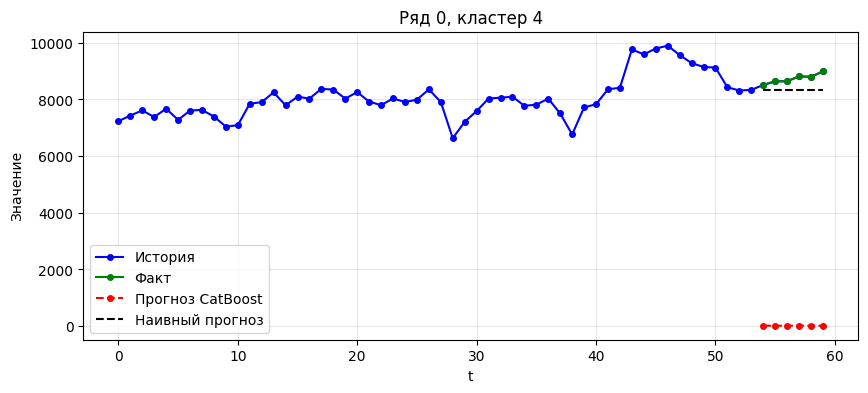

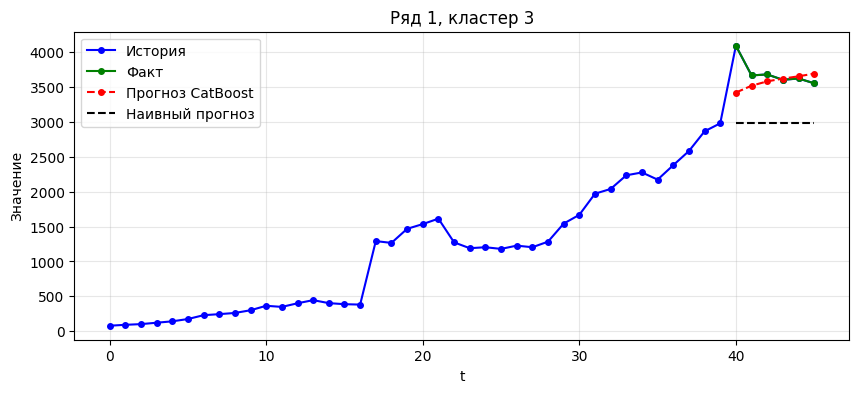

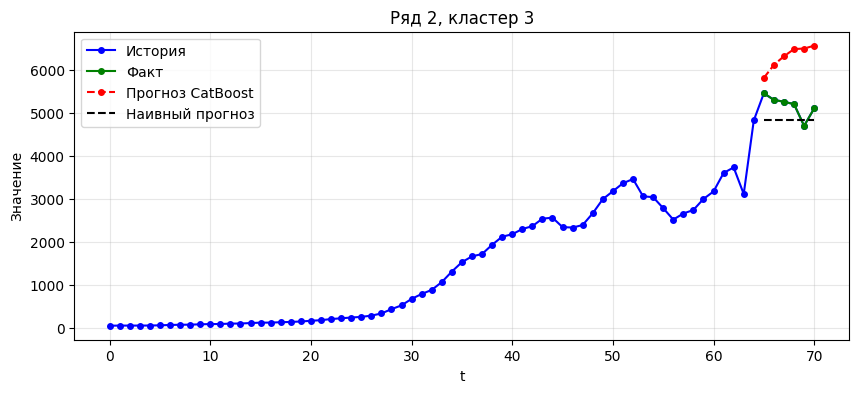

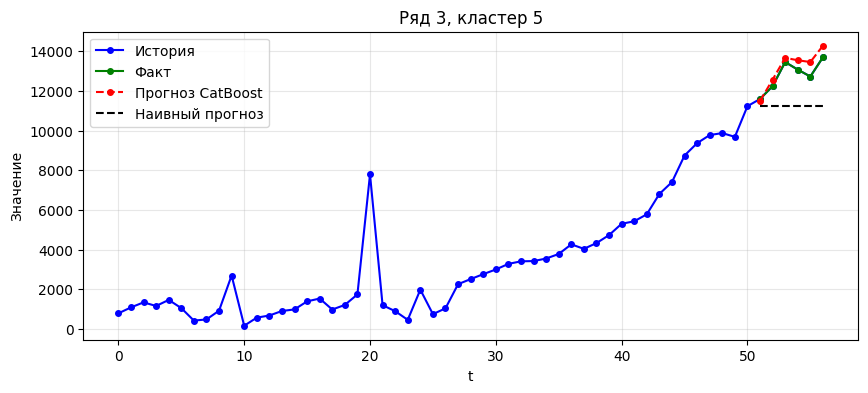

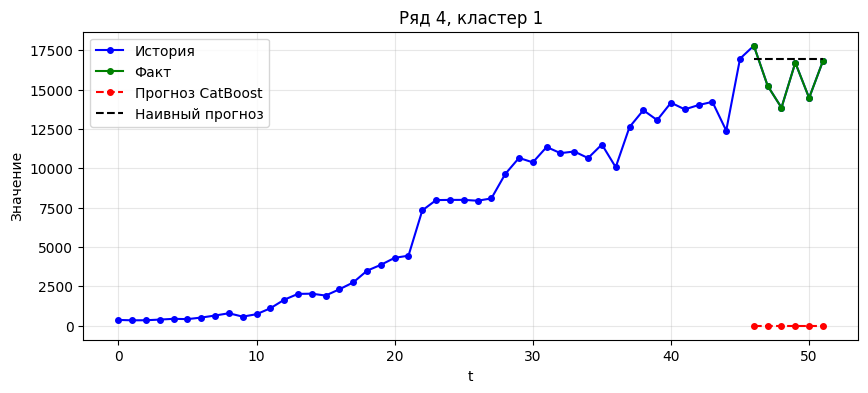

In [261]:
plot_forecasts(series_list, pred_real, true, row_indices, cluster_labels)

In [262]:
evaluate_all_by_cluster(pred_real, true, cluster_labels)

/var/folders/3_/2wr0327x7452dt9rf72yvcww0000gn/T/ipykernel_62162/1909119977.py:14: RuntimeWarning: overflow encountered in square
  return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))


,cluster,SMAPE_mean,MAE_mean,RMSE_mean
0,4,181.570898,4.267182e+128,4.267182e+128
1,3,173.098366,1.632450e+232,inf
2,5,171.816465,2.196249e+156,inf
3,1,191.296353,2.528120e+16,2.533400e+16
4,6,191.571989,2.513333e+23,2.513333e+23
5,2,188.710058,3.827754e+31,3.827754e+31
6,0,156.170266,5.160401e+50,5.160401e+50
7,overall,180.410433,3.913407e+231,inf
